## 미션 목표

- 흉부 X-Ray 사진을 바탕으로 폐렴 환자 구분

- Fine-Tuning 기법을 활용해 분류 모델 구축

## 활용 데이터셋

 : Kaggle의 Chest X-Ray Images (Pneumonia)



##파이프라인

**데이터 분석 -> 데이터 로더 구축 -> 학습/평가함수 구축 -> 1차 테스트(사전학습 모델들의 Feature Extraction) -> 2차 테스트(상위 2개 모델의 Fine-Tuning) -> 최종 모델 하이퍼파라미터 튜닝 -> 학습 -> 예측/평가**

##1\. 데이터 EDA

###필요 pip / import

In [49]:
!pip install kagglehub

In [50]:
!pip install torchmetrics

In [51]:
!pip install torchsummary

In [52]:
!pip install optuna

In [53]:
!pip install grad_cam

In [54]:
import kagglehub
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from PIL import Image
from pathlib import Path
from torchvision import transforms
import cv2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchmetrics import Accuracy, F1Score
import torch.optim as optim
import torch
import torch.nn as nn
from torchsummary import summary
import optuna
from pytorch_grad_cam import LayerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

로컬에 다운로드하여 진행하기 보다, 캐글에서 직접 코랩 캐시를 사용해 불러오는 방법을 선택했다.

In [55]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [56]:
print("Dataset path:", path)
print("Contents:", os.listdir(path))

Dataset path: /kaggle/input/chest-xray-pneumonia
Contents: ['chest_xray']


In [57]:
chest_xray_path = os.path.join(path, "chest_xray")
print("Chest X-ray folders:", os.listdir(chest_xray_path))

Chest X-ray folders: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [58]:
#chest-xray 폴더 내의 dir을 직접 접근하기 위해 변수에 path 할당
train_dir = os.path.join(chest_xray_path, "train")
test_dir  = os.path.join(chest_xray_path, "test")
val_dir   = os.path.join(chest_xray_path, "val")

###데이터셋 개수 시각화

폴더별로 몇 장의 이미지가 들어있는지 보기 위해서 DataFrame으로 만들어서 피벗 테이블 형태로 관찰했다.

In [59]:
#폴더별 이미지 개수 dataframe
data = []

for dir in [train_dir, val_dir, test_dir] :
  for label in ['NORMAL', 'PNEUMONIA'] :
    cnt = len(os.listdir(os.path.join(dir, label)))
    data.append([os.path.basename(dir), label, cnt])

df = pd.DataFrame(data, columns=['dir', 'label', 'count'])
df_pivot = df.pivot(index = 'dir', columns = 'label', values = 'count')
df_pivot = df_pivot.loc[['train', 'val', 'test']]
df_pivot.columns.name = None
df_pivot.index.name = None
df_pivot


,NORMAL,PNEUMONIA
train,1341,3875
val,8,8
test,234,390


- validation set의 크기가 Nomal 8 , Pneumonia 8로 매우 작은것을 확인

**test 셋을 분할하여 validation set으로 활용하기로 결정**

###데이터 시각화

X-Ray이기 때문에 GrayScale로 시각화하였다.

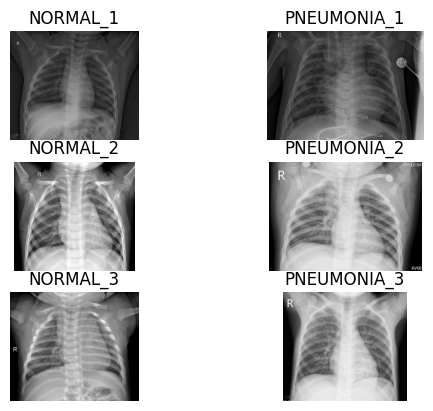

In [60]:
#이미지 시각화

#3장 가져오기
train_norm_imgs = os.listdir(os.path.join(train_dir, 'NORMAL'))[:3]
train_pneum_imgs = os.listdir(os.path.join(train_dir, 'PNEUMONIA'))[:3]

for i in range(3) :
  norm_path = os.path.join(train_dir, 'NORMAL', train_norm_imgs[i])
  pneum_path = os.path.join(train_dir, 'PNEUMONIA', train_pneum_imgs[i])

  norm_img = Image.open(norm_path)
  pneum_img = Image.open(pneum_path)

  #왼쪽 : Normal 이미지
  plt.subplot(3, 2, 2 * i + 1)
  plt.imshow(norm_img, cmap = 'gray')
  plt.title(f'NORMAL_{i+1}')
  plt.axis('off')

  #오른쪽 : Pneumonia 이미지
  plt.subplot(3, 2, 2 * i + 2)
  plt.imshow(pneum_img, cmap = 'gray')
  plt.title(f'PNEUMONIA_{i+1}')
  plt.axis('off')


###이미지 색상정보/ 이미지 크기 확인

이미지 Resize시에 크기를 너무 줄여버리면 성능에 악영향을 끼칠 수 있어 unique 크기를 보았고, 색상정보를 확인했다.

In [61]:
#이미지 색상정보, 이미지 크기 확인
full_image_path = []
for dir in [train_dir, val_dir, test_dir] :
  full_image_path += list(Path(dir).glob('*/*.jpeg'))

# 이미지 크기의 고유값을 보기 위해 set() 이용 (중복 방지)
image_sizes = set()
modes = set()

for image_path in full_image_path:
    with Image.open(image_path) as img:
        # mode : 이미지의 색상정보 (L : 흑백, RGB : 컬러)
        modes.add(img.mode)
        # size : 이미지의 크기
        image_sizes.add(img.size)
min_size = min(image_sizes, key=lambda x: x[0] * x[1])
max_size = max(image_sizes, key=lambda x: x[0] * x[1])
print(f'modes : {modes}')
print(f'image_sizes : {image_sizes}')
print(f'min_size : {min_size}, max_size : {max_size}')

modes : {'L', 'RGB'}
image_sizes : {(976, 544), (848, 624), (1994, 1839), (1416, 816), (1454, 1071), (1488, 984), (1762, 1224), (880, 576), (1532, 1256), (1794, 1176), (1496, 1333), (1318, 1067), (1592, 1041), (1630, 1333), (1364, 805), (1016, 616), (1856, 1496), (2434, 2376), (1778, 1168), (1322, 1037), (1328, 968), (1854, 1572), (1562, 1284), (1400, 1136), (920, 648), (1408, 960), (1712, 1488), (872, 608), (1360, 920), (1232, 1000), (1440, 800), (1846, 1488), (1624, 1375), (1786, 1437), (2746, 2382), (796, 469), (1136, 654), (1857, 1317), (888, 552), (840, 512), (1400, 1221), (1754, 1341), (2022, 1384), (1720, 1348), (792, 584), (1360, 776), (1542, 1341), (2096, 1864), (1256, 984), (928, 624), (1850, 1314), (1616, 1147), (1312, 1144), (2000, 1896), (760, 488), (812, 678), (1654, 1259), (1742, 1372), (2474, 2224), (1272, 928), (1224, 888), (1890, 1615), (1504, 1171), (816, 568), (1736, 1328), (1176, 960), (1256, 840), (928, 480), (2280, 2066), (1803, 1238), (1312, 1000), (832, 512), (

-> RGB, L 의 색상공간들을 가지고 있다 : 하지만 X-Ray 이므로 모두 L로 변환하기로 결정

-> 사전학습 모델도 활용할 계획이기 때문에 224 x 224 로 resize하기로 결정

## 2\. 데이터셋/ 데이터로더 구축

###Transforms 구성

학습데이터셋의 크기가 크지는 않기 때문에, 데이터 증강을 추가하기로 결정했다.

AutoAugment 정책 종류 :

|정책 종류|주요 변환|특징
|:---:|:---:|:---:|
|IMAGENET|색상조정/밝기/대비 조정|다양한 컬러 이미지 최적화|
|CIFAR10|회전/이동 위주|형태/구조 변경에 강함
|SHVN|대비, 균등화, 색조 변환 위주|숫자/문자 인식용으로 설계|


AutoAugment를 활용하여 데이터 증강을 진행하기로 결정하였는데, 위의 표에 따라서 **CIFAR10 정책**으로 진행하기로 결정하였다.

또한 타일별 히스토그램 균일화(CLAHE)를 적용하는 것이 X-Ray 이미지 전처리에서 중요해 적용해주었다.

In [62]:
auto_policy = transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.CIFAR10)

#CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

def apply_clahe(img):
    img = np.array(img.convert('L'))
    img = clahe.apply(img)
    return Image.fromarray(img)

In [63]:
#transform Compose

#train_transform(데이터 증강 o)
train_trasfroms = transforms.Compose([
    transforms.Lambda(lambda img : apply_clahe(img)), #clahe 적용
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    auto_policy,
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                     std=[0.5, 0.5, 0.5])
])

val_test_transforms = transforms.Compose([
    transforms.Lambda(lambda img : apply_clahe(img)), #clahe 적용
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                     std=[0.5, 0.5, 0.5])
])

###이미지 데이터셋 추출

위에서 validation set 개수가 적어 test 데이터를 random split하여 가져오기로 하여, 진행했다.

폴더 이름으로 라벨링을 진행하기 위해서 ImageFolder로 데이터셋을 읽어왔다.

In [64]:
#Train Data 데이터세트 추출
train_dataset = ImageFolder(train_dir, transform = train_trasfroms)

#val, test 데이터 random split
val_test_dataset = ImageFolder(test_dir, transform = val_test_transforms)
val_size = int(0.5 * len(val_test_dataset))
test_size = len(val_test_dataset) - val_size

val_dataset, test_dataset = random_split(val_test_dataset, [val_size, test_size])
print(f'데이터셋 라벨 : {train_dataset.class_to_idx}')

데이터셋 라벨 : {'NORMAL': 0, 'PNEUMONIA': 1}


###데이터로더 생성

In [65]:
#데이터로더 생성
train_loader = DataLoader(train_dataset, batch_size = 256,
                          shuffle = True, num_workers = 2,
                          persistent_workers=True, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size = 32,
                        shuffle= False, num_workers = 2,
                        persistent_workers=True, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = 32,
                         shuffle = False, num_workers = 2,
                         persistent_workers=True, pin_memory = True)

#첫 번째 배치의 shape 출
img, label = next(iter(train_loader))
print(img.shape, label.shape)

torch.Size([256, 3, 224, 224]) torch.Size([256])


## 3\. 학습/평가 함수 구축

여러 모델들과 여러 fine-tuning 기법을 비교하기 위해서 반복적으로 호출할 학습/평가 함수를 정의했다.

In [66]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [99]:
def train_test(model, model_name, train_loader, val_loader, epochs, lr, wd, device,
               unfreeze = None) :
  model.to(device)

  #옵티마이저 설정(전이학습의 파라미터 관리, 메모리 효율성을 위해 filter 사용)
  optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                          lr = lr, weight_decay = wd)

  criterion = nn.BCEWithLogitsLoss()  #이진분류이기 때문에 BCEWithLogitsLoss() 사용

  #성능지표
  accuracy = Accuracy(task = 'binary').to(device)
  f1 = F1Score(task = 'binary').to(device)

  #스케줄러
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       mode = 'max',
                                                       patience = 5,
                                                       factor = 0.5)

  #학습 기록
  history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[], 'time' : 0.0}
  best_f1 = 0.0
  best_epoch = 0
  stop_patience = 15
  stopping_cnt = 0

  #체크포인트
  os.makedirs('checkpoints', exist_ok = True)
  print('학습 시작')

  start_time = time.time()
  for epoch in range(epochs) :
    #단계적 unfreeze를 진행할 시에 작동되는 조건문(optimizer reset)
    if unfreeze is not None :
      if unfreeze_layers(model, epoch, unfreeze) :
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                          lr = lr, weight_decay = wd)

    model.train()
    t_loss = 0
    for idx, (img, label) in enumerate(train_loader) :
      img = img.to(device)
      #BCEWithLogitsLoss()활용으로 인해 shape 맞추기 위해 unsqueeze
      label = label.float().unsqueeze(1).to(device)

      #forward
      output = model(img)
      loss = criterion(output, label)

      #backward
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      t_loss += loss.item()
      if (idx+1) % 50 == 0: print('.', end='')

    avg_t_loss = t_loss / len(train_loader)
    history['train_loss'].append(avg_t_loss)

    #Validation
    model.eval()
    accuracy.reset()
    f1.reset()
    v_loss = 0

    with torch.no_grad() :
      for idx, (img, label) in enumerate(val_loader) :
        img = img.to(device)
        label = label.float().unsqueeze(1).to(device)

        output = model(img)
        loss = criterion(output, label)
        #metrics 계산을 위한 sigmoid
        pred = torch.sigmoid(output)

        #성능지표 계산
        v_loss += loss.item()
        accuracy.update(pred, label)
        f1.update(pred, label)

    acc = accuracy.compute().item()
    f1_score = f1.compute().item()
    avg_v_loss = v_loss / len(val_loader)

    history['val_loss'].append(avg_v_loss)
    history['val_acc'].append(acc)
    history['val_f1'].append(f1_score)

    scheduler.step(f1_score)
    if f1_score > best_f1 :
      best_f1 = f1_score
      best_epoch = epoch + 1
      torch.save(model.state_dict(), f'checkpoints/{model_name}_best_model.pt')
      print(f"Best 모델 갱신 (Epoch {best_epoch}, F1: {best_f1:.6f})")
      stopping_cnt = 0 #stopping count 리셋

    else :
      stopping_cnt += 1
      #Early-Stopping
      if stopping_cnt >= stop_patience :
        print(f"Early Stopping at {epoch+1} Epoch)")
        break
    if (epoch + 1) % 10 == 0:
      print(f'Epoch [{epoch+1}/{epochs}] 완료 , Best Epoch : {best_epoch} , Best F1 :{best_f1:.6f}')

  end_time = time.time()
  history['time'] = end_time - start_time

  print('학습 종료')
  print(f'모델 : {model.__class__.__name__}, 소요시간 : {end_time - start_time: .5f} (sec)')
  print(f"최적 F1 에포크: {best_epoch}, 최고 F1 스코어: {best_f1:.6f}")
  return history



- BCEWithLogitLoss에는 sigmoid처리가 들어있어서 Loss 계산에는 하지 않아도 되지만, metric 계산시에는 확률 계산을 위해서 sigmoid 처리하였다.

- 추후에 전이학습을 위해서 사용되는 파라미터만 업데이트하도록 filter를 사용하여 구축하였다.

## 4\. 1차 테스트(Feature Exraction)

사전학습된 모델로는 **ResNet, EfficientNet, ConvNext, DenseNet**모델을 튜닝한 모델들을 불러와 전이학습을 통해 성능지표를 관찰했다.

Feature Extraction을 총 4개에 모델에 대해서 적용한 후, 가장 좋은 성능지표를 보이는 상위 2개 모델에 대해서 fine_tuning을 진행하기로 하였다.

또한 모든 Fine-Tuning에 대해서 첫번째 layer은 너무 큰 초반 저수준 feature를 담당하여서 과적합 위험이 올라가고, 학습 시간이 늘어나는것을 고려해 unfreeze하지 않았다.

- ResNet : Skip connection으로 기울기 소실 문제 완화한 모델

- EfficientNet : 네트워크의 깊이, 너비, 해상도를 균형있게 스케일링해 효율성을 극대화한 모델

- DenseNet : 모든 레이어를 연결해 feature을 최대한 재사용하는 모델

- ConvNeXt : Vision Transformer의 장점을 CNN에 접목하여 성능을 끌어올린 모델

|모델|장점|단점|
|:---:|:---|:---|
|ResNet|구조 단순, 범용적, 레퍼런스 많음| 깊어질수록 파라미터 많아짐|
|EfficientNet|적은 파라미터로 높은 성능, 경량화|구조 복잡, 커스터마이징 어려움|
|DenseNet|Feature 재사용으로 파라미터 효율적|메모리 사용량 많음|
|ConvNeXt|최신 모델로 성능 우수, ViT 장점 흡수| 학습 리소스 많이 필요, 레퍼런스 적음|

### 반복 함수 정의

반복적으로 성능지표과 시각화를 진행해야하기 때문에 함수를 정의해 반복작업을 최소화했다.

In [68]:
from torchvision.models import resnet18, efficientnet_b1, convnext_tiny, densenet121

In [69]:
#튜닝한 모델들의 성능지표를 담을 dict 생성
fe_model_dict = {}

In [70]:
#model_dict에 기록하는 함수 정의
def save_model_dict(model_name, model_dict, history):
  best_epoch = np.argmax(history['val_f1'])

  model_dict[model_name] = {
      "time": history["time"],
      "best_f1": history["val_f1"][best_epoch],
      "best_acc": history["val_acc"][best_epoch],
      "best_loss": history["val_loss"][best_epoch]
  }

In [71]:
#history 시각화 함수 정의
def plot_history(history) :
  epochs_range = range(1, len(history['train_loss'])+1)

  plt.figure(figsize=(8, 8))

  # 학습&평가 손실 시각화
  ax1 = plt.subplot(2, 1, 1)
  ax1.plot(epochs_range, history['train_loss'], label= 'train_loss')
  ax1.plot(epochs_range, history['val_loss'], label= 'val_loss')
  ax1.set_title('Training vs Val Loss')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.legend()

  # 정확도&F1 지표 시각화
  ax2 = plt.subplot(2, 1, 2)
  ax2.plot(epochs_range, history['val_acc'], label='val_acc')
  ax2.plot(epochs_range, history['val_f1'], label='val_f1')
  ax2.set_title('Validation Accuracy & F1')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Score')
  ax2.legend()


  plt.legend()
  plt.tight_layout()
  plt.show()

단계적 Unfreeze 함수 정의 : Unfreeze될때마다 unfreeze된 레이어를 print하도록 함수를 정의하였다.

In [72]:
#단계별 unfreeze 함수 정의
def unfreeze_layers(model, epoch, unfreeze, step=3):
    if (epoch + 1) > (len(unfreeze) * step):
        return

    if (epoch + 1) % step == 0:
        layer_idx = (epoch + 1) // step
        target_layer = unfreeze[layer_idx - 1]
        for param in target_layer.parameters():
            param.requires_grad = True
        print(f'\n[Unfreeze] {layer_idx - 1}번째 상위 블록이 해제되었습니다.')

        return True

모델 비교를 할 때에 고정되지 않을 변수로는 unfreeze, model, model_name 밖에 없기 때문에 위에서 선언한 함수들을 모두 통합한 함수를 가독성을 위해 선언했다.

ResNet일 경우만 분류기 이름이 model.fc이고, 나머지는 model.classifier로 저장되어 있어 조건문을 추가했다.

In [73]:
def compare_models(model, model_name, epochs, model_dict, unfreeze = None) :
  # 모델의 모든 가중치를 프리징
  for param in model.parameters():
      param.requires_grad = False

  # classifier 계층만 프리징을 해제
  if model.__class__.__name__ == 'ResNet' :
    for param in model.fc.parameters():
        param.requires_grad = True
  else :
    for param in model.classifier.parameters():
        param.requires_grad = True



  history = train_test(model,
                     model_name,
                    train_loader,
                    val_loader,
                    epochs = epochs,
                    lr = 1e-4,
                     wd = 1e-4,
                    device = 'cuda' if torch.cuda.is_available() else 'cpu',
                    unfreeze = unfreeze
                    )

  save_model_dict(model_name, model_dict, history)
  print('Model_Dict 저장 완료 !')
  plot_history(history)

### a) ResNet - Feature Extraction

In [74]:
model = resnet18(weights="IMAGENET1K_V1")
#fe : feature extraction
model_name = 'resnet_fe'

# Before fc레이어 출력
print("Before  : \n")
print(model.fc)

#새로우 fc레이어 할당(이진분류)
new_classifier = nn.Linear(512, 1)
model.fc = new_classifier

#이후 fc레이어 출력
print("After : \n")
print(model.fc)

Before  : 

Linear(in_features=512, out_features=1000, bias=True)
After : 

Linear(in_features=512, out_features=1, bias=True)


In [75]:
for name, module in model.named_children():
    print(f"{name} : {module.__class__.__name__}")

conv1 : Conv2d
bn1 : BatchNorm2d
relu : ReLU
maxpool : MaxPool2d
layer1 : Sequential
layer2 : Sequential
layer3 : Sequential
layer4 : Sequential
avgpool : AdaptiveAvgPool2d
fc : Linear


학습 시작
Best 모델 갱신 (Epoch 1, F1: 0.785992)
Best 모델 갱신 (Epoch 2, F1: 0.790607)
Best 모델 갱신 (Epoch 3, F1: 0.792969)
Best 모델 갱신 (Epoch 4, F1: 0.794521)
Best 모델 갱신 (Epoch 5, F1: 0.799213)
Best 모델 갱신 (Epoch 6, F1: 0.805556)
Best 모델 갱신 (Epoch 7, F1: 0.809619)
Best 모델 갱신 (Epoch 8, F1: 0.816162)
Best 모델 갱신 (Epoch 9, F1: 0.817073)
Best 모델 갱신 (Epoch 10, F1: 0.824742)
Epoch [10/10] 완료 , Best Epoch : 10 , Best F1 :0.824742
학습 종료
모델 : ResNet, 소요시간 :  770.89388 (sec)
최적 F1 에포크: 10, 최고 F1 스코어: 0.824742
Model_Dict 저장 완료 !


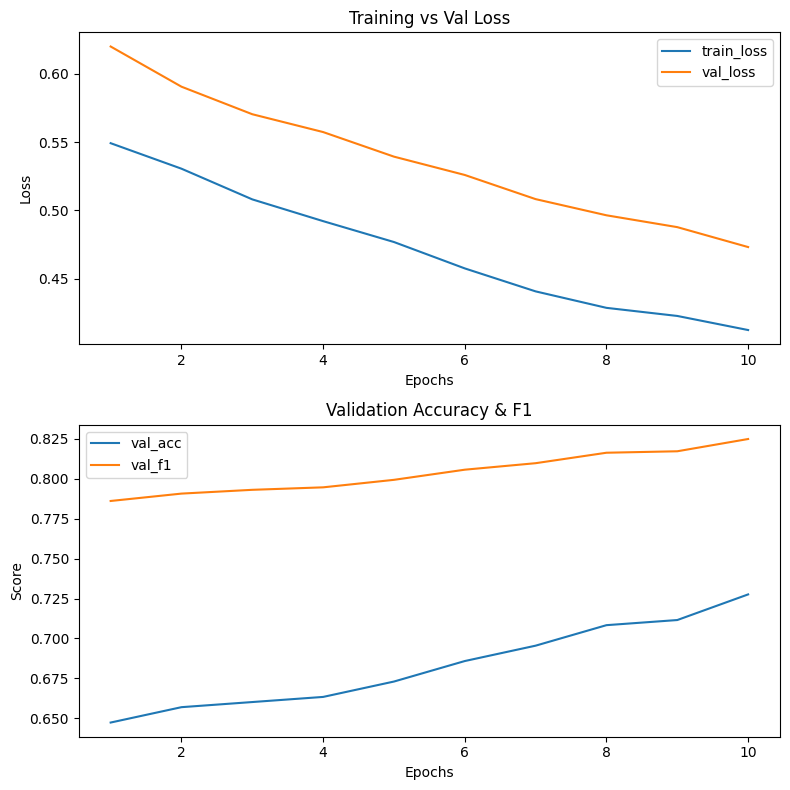

In [76]:
compare_models(model, model_name, epochs = 10, model_dict= fe_model_dict)

### b) EfficientNet - Feature Extraction

In [77]:
model = efficientnet_b1(weights = 'IMAGENET1K_V1')
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [78]:
model = efficientnet_b1(weights = 'IMAGENET1K_V1')
model_name = 'efficientnet_fe'

# Before classifier 출력
print("Before  : \n")
print(model.classifier)

new_classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=1280, out_features=256),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.2),
    torch.nn.Linear(in_features=256, out_features=1)
)

model.classifier = new_classifier

#After Classfier 출력
print("After : \n")
print(model.classifier)

Before  : 

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
After : 

Sequential(
  (0): Linear(in_features=1280, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=1, bias=True)
)


In [79]:
for name, module in model.features.named_children():
    print(f"{name} : {module.__class__.__name__}")

0 : Conv2dNormActivation
1 : Sequential
2 : Sequential
3 : Sequential
4 : Sequential
5 : Sequential
6 : Sequential
7 : Sequential
8 : Conv2dNormActivation


학습 시작
Best 모델 갱신 (Epoch 1, F1: 0.791423)
Best 모델 갱신 (Epoch 2, F1: 0.831276)
Best 모델 갱신 (Epoch 3, F1: 0.842553)
Best 모델 갱신 (Epoch 4, F1: 0.885906)
Best 모델 갱신 (Epoch 5, F1: 0.895455)
Best 모델 갱신 (Epoch 6, F1: 0.899767)
Best 모델 갱신 (Epoch 7, F1: 0.900693)
Best 모델 갱신 (Epoch 9, F1: 0.901149)
Best 모델 갱신 (Epoch 10, F1: 0.904429)
Epoch [10/10] 완료 , Best Epoch : 10 , Best F1 :0.904429
학습 종료
모델 : EfficientNet, 소요시간 :  760.97143 (sec)
최적 F1 에포크: 10, 최고 F1 스코어: 0.904429
Model_Dict 저장 완료 !


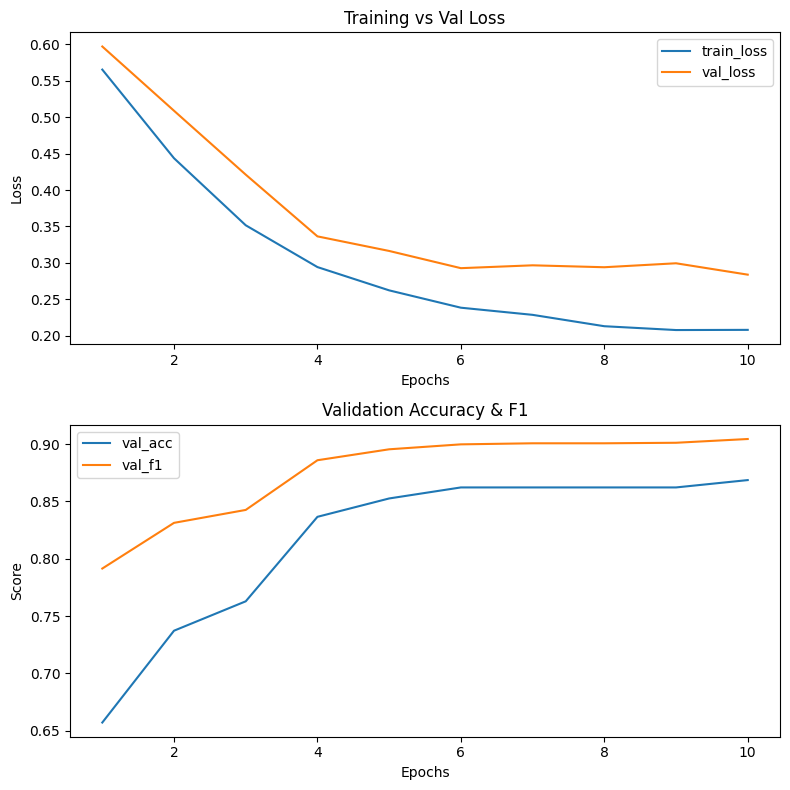

In [80]:
compare_models(model, model_name, epochs = 10, model_dict= fe_model_dict)

### c) DenseNet - Feature Extraction

In [81]:
model = densenet121(weights = 'IMAGENET1K_V1')
model_name = 'densenet_fe'

print("Before  : \n")
print(model.classifier)

new_classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=1024, out_features=256),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.2),
    torch.nn.Linear(in_features=256, out_features=1)
)

model.classifier = new_classifier

#After Classfier 출력
print("After : \n")
print(model.classifier)

Before  : 

Linear(in_features=1024, out_features=1000, bias=True)
After : 

Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=1, bias=True)
)


In [82]:
for name, module in model.features.named_children():
    print(f"{name} : {module.__class__.__name__}")

conv0 : Conv2d
norm0 : BatchNorm2d
relu0 : ReLU
pool0 : MaxPool2d
denseblock1 : _DenseBlock
transition1 : _Transition
denseblock2 : _DenseBlock
transition2 : _Transition
denseblock3 : _DenseBlock
transition3 : _Transition
denseblock4 : _DenseBlock
norm5 : BatchNorm2d


학습 시작
Best 모델 갱신 (Epoch 1, F1: 0.788350)
Best 모델 갱신 (Epoch 3, F1: 0.831967)
Best 모델 갱신 (Epoch 4, F1: 0.857143)
Best 모델 갱신 (Epoch 5, F1: 0.866521)
Best 모델 갱신 (Epoch 6, F1: 0.870330)
Best 모델 갱신 (Epoch 7, F1: 0.885393)
Best 모델 갱신 (Epoch 8, F1: 0.893424)
Epoch [10/10] 완료 , Best Epoch : 8 , Best F1 :0.893424
학습 종료
모델 : DenseNet, 소요시간 :  760.55172 (sec)
최적 F1 에포크: 8, 최고 F1 스코어: 0.893424
Model_Dict 저장 완료 !


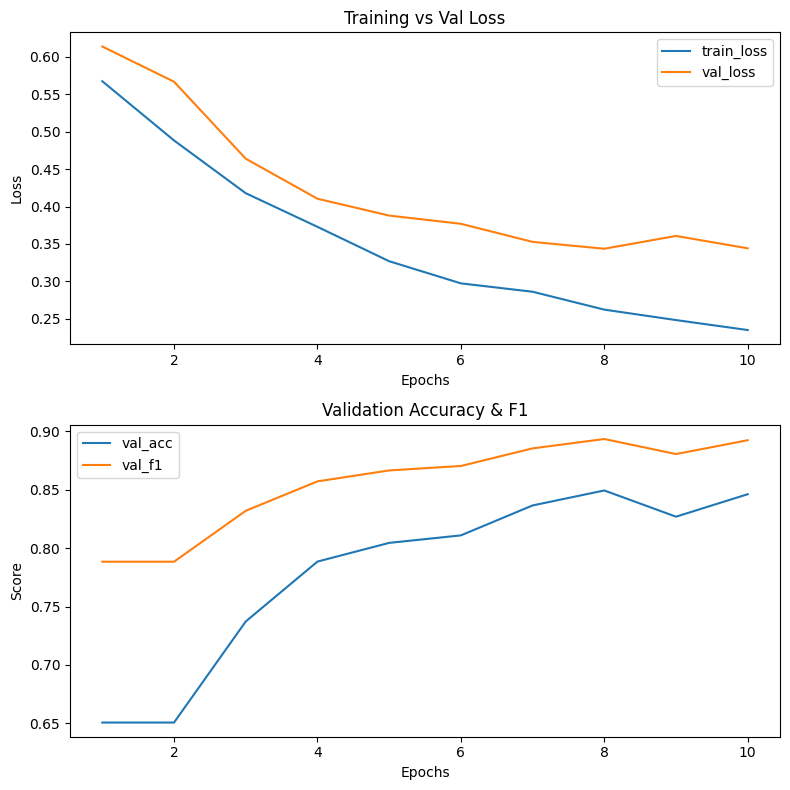

In [83]:
compare_models(model, model_name, epochs = 10, model_dict= fe_model_dict)

### d) ConvNeXt - Feature Extraction

In [84]:
model = convnext_tiny(weights = 'IMAGENET1K_V1')
model_name = 'convnext_fe'

print("Before  : \n")
print(model.classifier)

model.classifier[-1] = nn.Linear(768, 1)

print("After : \n")
print(model.classifier)

Before  : 

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1000, bias=True)
)
After : 

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1, bias=True)
)


학습 시작
Best 모델 갱신 (Epoch 1, F1: 0.788350)
Best 모델 갱신 (Epoch 6, F1: 0.791423)
Best 모델 갱신 (Epoch 7, F1: 0.796078)
Best 모델 갱신 (Epoch 8, F1: 0.801587)
Best 모델 갱신 (Epoch 9, F1: 0.809619)
Best 모델 갱신 (Epoch 10, F1: 0.813765)
Epoch [10/10] 완료 , Best Epoch : 10 , Best F1 :0.813765
학습 종료
모델 : ConvNeXt, 소요시간 :  757.05731 (sec)
최적 F1 에포크: 10, 최고 F1 스코어: 0.813765
Model_Dict 저장 완료 !


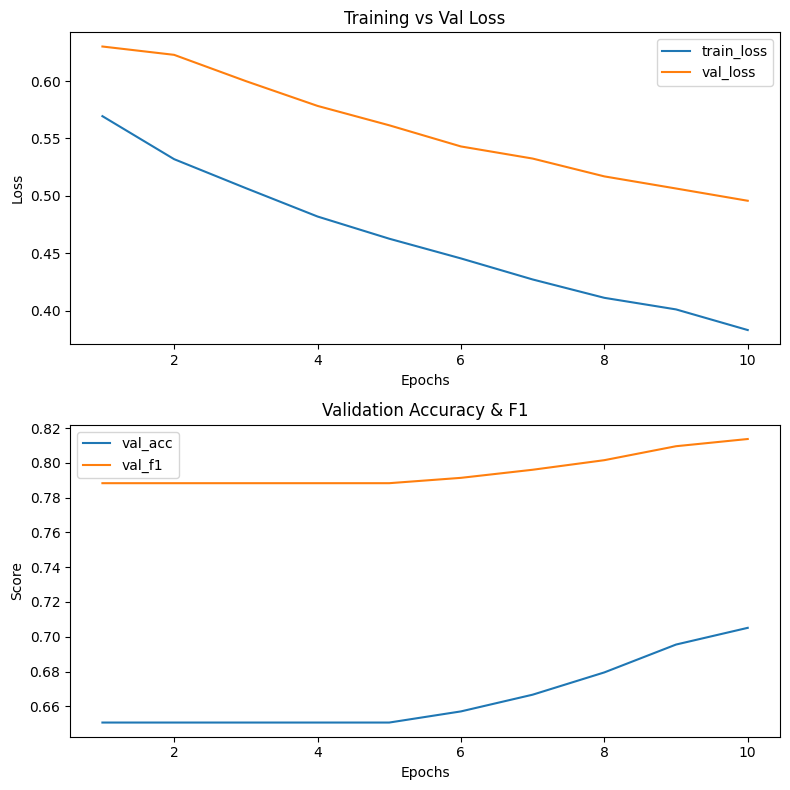

In [85]:
compare_models(model, model_name, epochs = 10, model_dict= fe_model_dict)

###1차 테스트 시각화

In [86]:
first_test_df = pd.DataFrame(fe_model_dict).T

#가장 좋은 지표를 bold처리
def highlight_best(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)

    # 클수록 좋은 컬럼
    for col in ['best_f1', 'best_acc']:
        styles.loc[df[col].idxmax(), col] = 'font-weight: bold'

    # 작을수록 좋은 컬럼
    for col in ['best_loss', 'time']:
        styles.loc[df[col].idxmin(), col] = 'font-weight: bold'

    return styles

first_test_df.style.apply(highlight_best, axis=None)

,time,best_f1,best_acc,best_loss
resnet_fe,770.893876,0.824742,0.727564,0.473153
efficientnet_fe,760.971427,0.904429,0.868590,0.283768
densenet_fe,760.551720,0.893424,0.849359,0.343577
convnext_fe,757.057309,0.813765,0.705128,0.495745


그래프의 값 차이를 명확히 보기 위해서 logscale을 취해주었다.

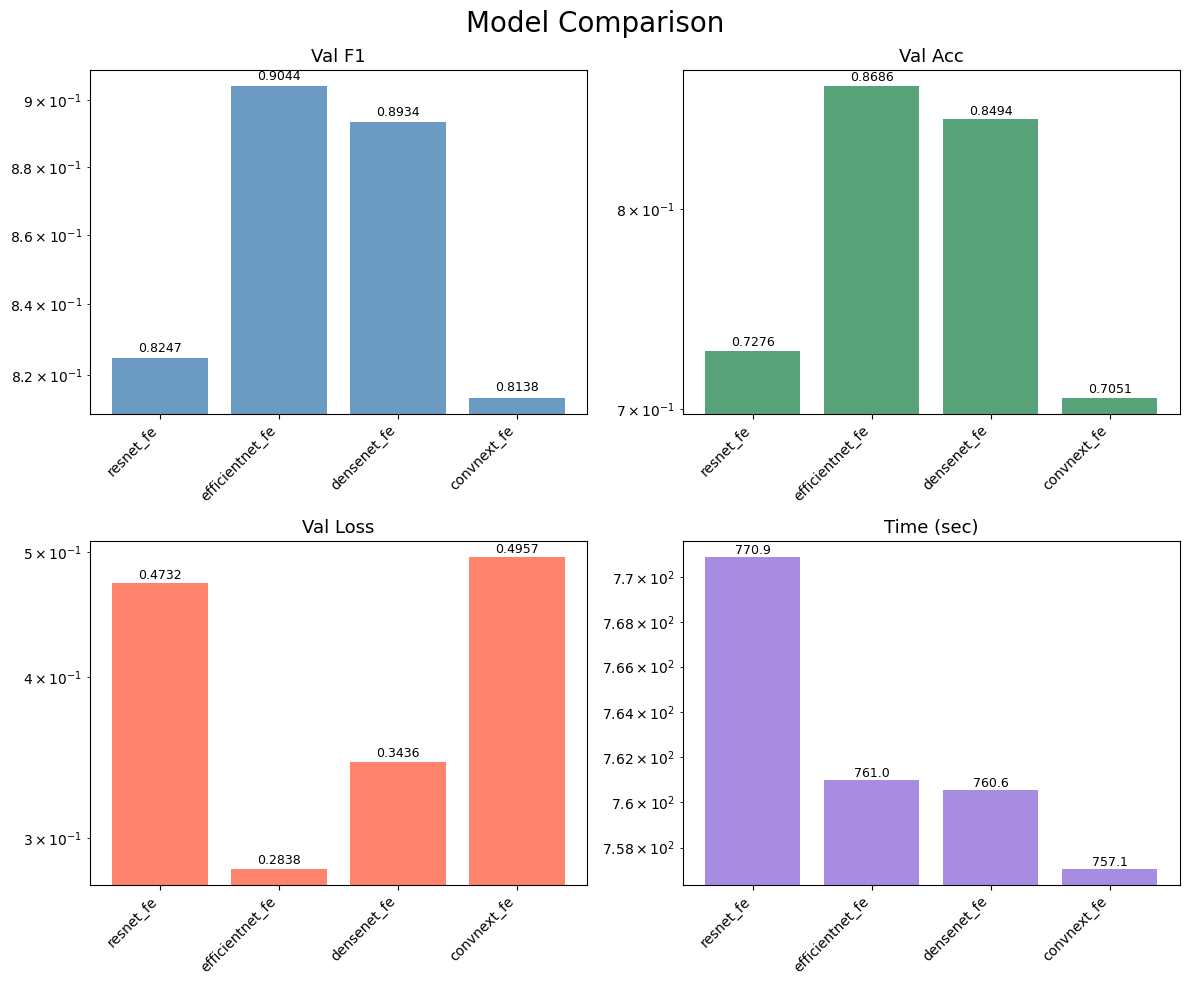

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Model Comparison', fontsize = 20)

metrics = ['best_f1', 'best_acc', 'best_loss', 'time']
titles = ['Val F1', 'Val Acc', 'Val Loss', 'Time (sec)']
colors = ['steelblue', 'seagreen', 'tomato', 'mediumpurple']
formats = ['.4f', '.4f', '.4f', '.1f']  # time은 소수점 1자리


for ax, metric, title, color, fmt in zip(axes.flatten(), metrics, titles, colors, formats):
    bars = ax.bar(first_test_df.index, first_test_df[metric], color=color, alpha=0.8)
    ax.set_title(title, fontsize=13)
    ax.set_xticks(range(len(first_test_df.index)))
    ax.set_xticklabels(first_test_df.index, rotation=45, ha='right')
    ax.set_yscale('log')  #값 차이를 명확히 보기 위해서 logscale

    for bar, val in zip(bars, first_test_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:{fmt}}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**-> 준수한 실행시간과, 높은 성능을 보인 EfficientNet, DenseNet이 1차 테스트를 합격했다 !**

## 5\. 2차 테스트(Fine-Tuning)

Fine-Tuning 기법으로는 Feature Extraction부터 분류기에 가까운 모델부터 순차적으로 unfreeze하는 기법을 사용했다.

In [88]:
FT_model_dict = {}

### a) EfficientNet - Fine Tuning

In [89]:
model = efficientnet_b1(weights = 'IMAGENET1K_V1')
model_name = 'efficientnet_fine_tuning'

# Before classifier 출력
print("Before  : \n")
print(model.classifier)

new_classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=1280, out_features=256),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.2),
    torch.nn.Linear(in_features=256, out_features=1)
)

model.classifier = new_classifier

print("After : \n")
print(model.classifier)

Before  : 

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
After : 

Sequential(
  (0): Linear(in_features=1280, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=1, bias=True)
)


학습 시작
Best 모델 갱신 (Epoch 1, F1: 0.791423)
Best 모델 갱신 (Epoch 2, F1: 0.835759)

[Unfreeze] 0번째 상위 블록이 해제되었습니다.
Best 모델 갱신 (Epoch 3, F1: 0.861538)
Best 모델 갱신 (Epoch 4, F1: 0.901602)
Best 모델 갱신 (Epoch 5, F1: 0.903670)

[Unfreeze] 1번째 상위 블록이 해제되었습니다.
Best 모델 갱신 (Epoch 6, F1: 0.906977)
Best 모델 갱신 (Epoch 7, F1: 0.911628)

[Unfreeze] 2번째 상위 블록이 해제되었습니다.
Epoch [10/15] 완료 , Best Epoch : 7 , Best F1 :0.911628

[Unfreeze] 3번째 상위 블록이 해제되었습니다.
학습 종료
모델 : EfficientNet, 소요시간 :  1132.51746 (sec)
최적 F1 에포크: 7, 최고 F1 스코어: 0.911628
Model_Dict 저장 완료 !


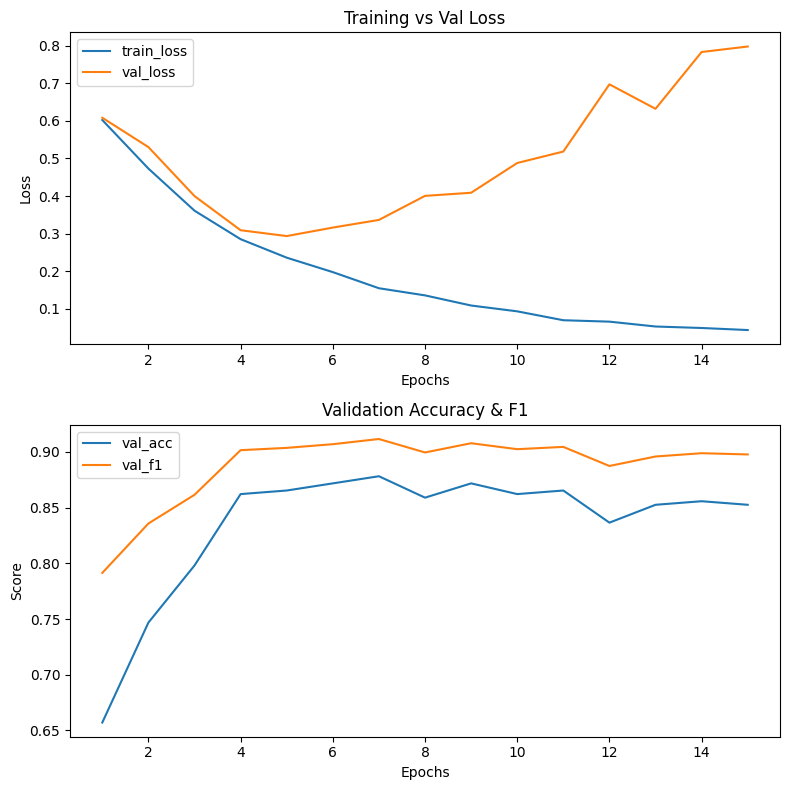

In [90]:
#unfreeze할 레이어 설정
unfreeze = [
  model.features[-1],
  model.features[-2],
  model.features[-3],
  model.features[-4]
]
compare_models(model, model_name, epochs = 15, model_dict= FT_model_dict, unfreeze = unfreeze)

### b) DenseNet - Fine Tuning

In [91]:
model = densenet121(weights = 'IMAGENET1K_V1')
model_name = 'densenet_fine_tuning'

print("Before  : \n")
print(model.classifier)

new_classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=1024, out_features=256),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.2),
    torch.nn.Linear(in_features=256, out_features=1)
)

model.classifier = new_classifier

#After Classfier 출력
print("After : \n")
print(model.classifier)

Before  : 

Linear(in_features=1024, out_features=1000, bias=True)
After : 

Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=1, bias=True)
)


학습 시작
Best 모델 갱신 (Epoch 1, F1: 0.788350)
Best 모델 갱신 (Epoch 2, F1: 0.789883)

[Unfreeze] 0번째 상위 블록이 해제되었습니다.
Best 모델 갱신 (Epoch 3, F1: 0.885906)
Best 모델 갱신 (Epoch 4, F1: 0.892377)

[Unfreeze] 1번째 상위 블록이 해제되었습니다.
Best 모델 갱신 (Epoch 7, F1: 0.895323)

[Unfreeze] 2번째 상위 블록이 해제되었습니다.
Epoch [10/15] 완료 , Best Epoch : 7 , Best F1 :0.895323
Best 모델 갱신 (Epoch 11, F1: 0.895787)
학습 종료
모델 : DenseNet, 소요시간 :  1139.40272 (sec)
최적 F1 에포크: 11, 최고 F1 스코어: 0.895787
Model_Dict 저장 완료 !


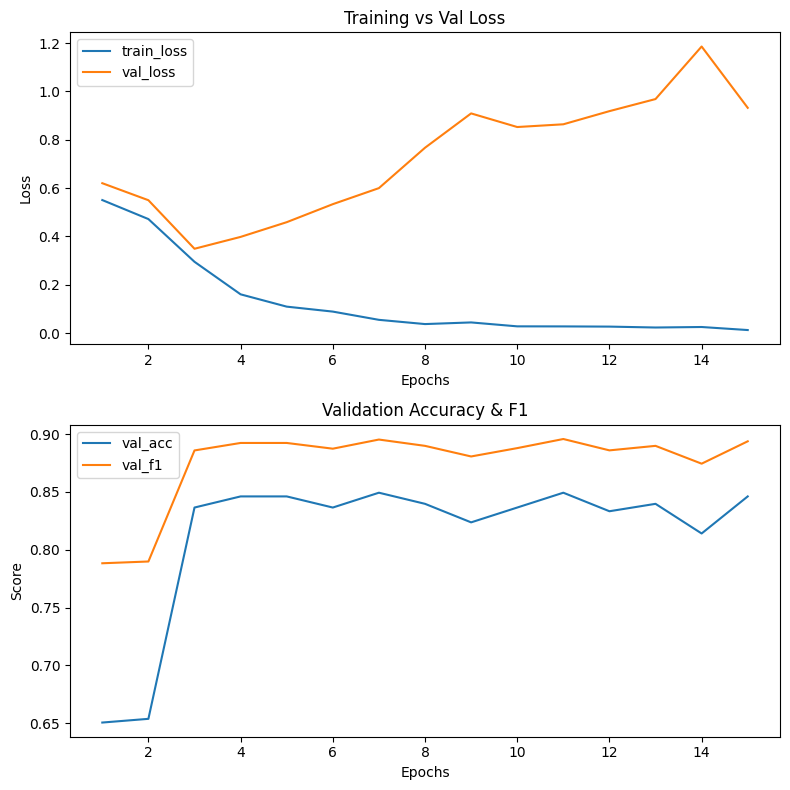

In [92]:
unfreeze = [
    model.features.denseblock4,
    model.features.denseblock3,
    model.features.denseblock2
]

compare_models(model, model_name, epochs = 15, model_dict= FT_model_dict, unfreeze = unfreeze)

### 2차 테스트 시각화

1차 테스트와 같은 방법으로 DataFrame형태와, 시각화를 통해 성능지표를 확인했다.

In [93]:
#표(DataFrame) 시각화
second_test_df = pd.DataFrame(FT_model_dict).T

#first test에서 사용했던 함수 사용
second_test_df.style.apply(highlight_best, axis=None)

,time,best_f1,best_acc,best_loss
efficientnet_fine_tuning,1132.517457,0.911628,0.878205,0.336484
densenet_fine_tuning,1139.402724,0.895787,0.849359,0.863878


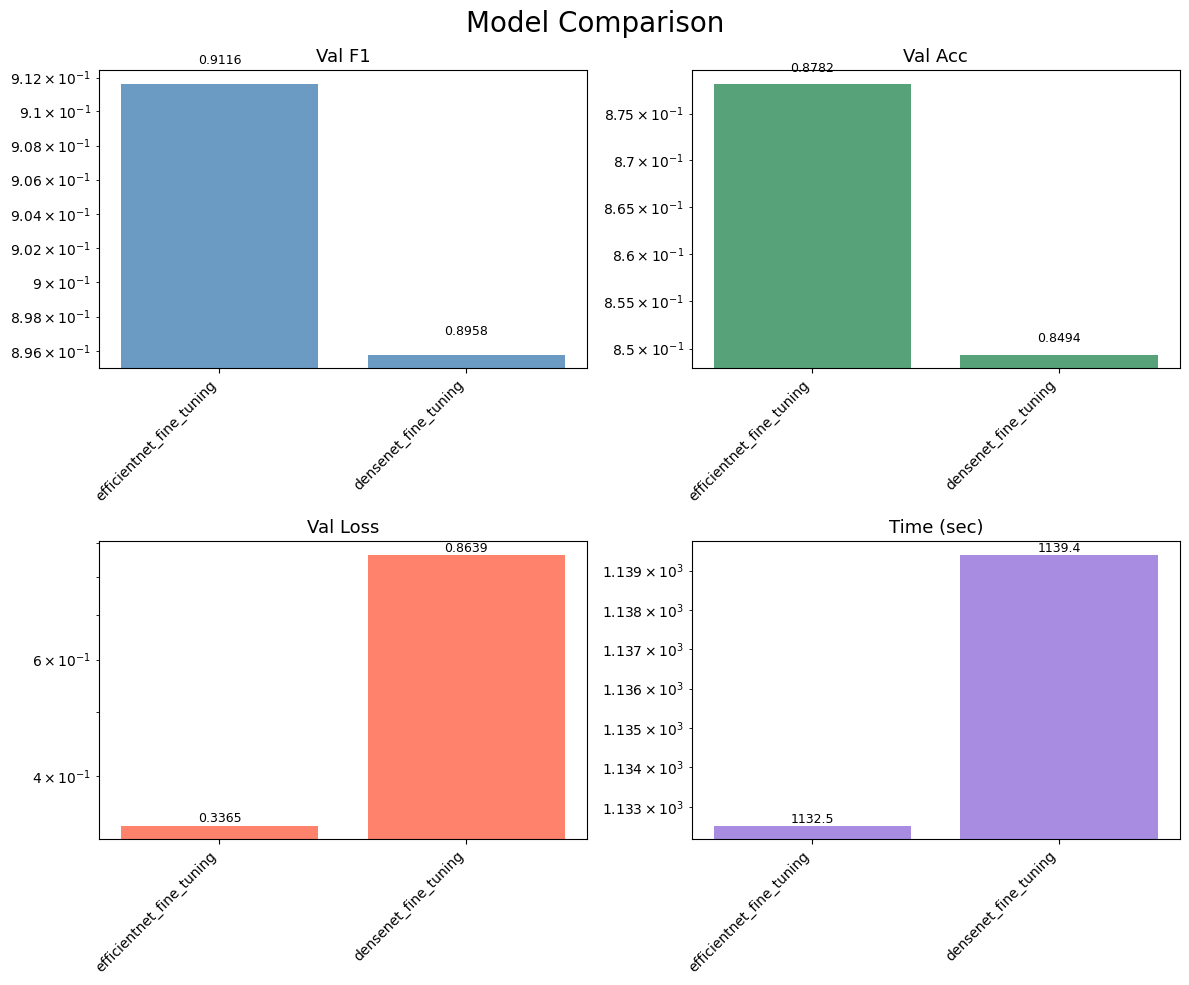

In [94]:
# 막대그래프 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Model Comparison', fontsize = 20)

metrics = ['best_f1', 'best_acc', 'best_loss', 'time']
titles = ['Val F1', 'Val Acc', 'Val Loss', 'Time (sec)']
colors = ['steelblue', 'seagreen', 'tomato', 'mediumpurple']
formats = ['.4f', '.4f', '.4f', '.1f']  # time은 소수점 1자리


for ax, metric, title, color, fmt in zip(axes.flatten(), metrics, titles, colors, formats):
    bars = ax.bar(second_test_df.index, second_test_df[metric], color=color, alpha=0.8)
    ax.set_title(title, fontsize=13)
    ax.set_xticks(range(len(second_test_df.index)))
    ax.set_xticklabels(second_test_df.index, rotation=45, ha='right')
    ax.set_yscale('log')  #값 차이를 명확히 보기 위해서 logscale


    for bar, val in zip(bars, second_test_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:{fmt}}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Fine-Tuning에 걸렸던 시간, 성능지표면에서 EfficientNet이 더 좋은 지표를 보였기 때문에 **최종 모델은 Fine-Tuning된 EfficientNet으로 결정하게 되었다.**

## 6\. 하이퍼파라미터 튜닝

2차 테스트에서 더 나은 성능지표를 보인 모델인 EfficientNet을 가져와 learning_rate, weight_decay에 대해서 하이퍼파라미터 튜닝을 진행했다.

하이퍼파라미터 튜닝에 대해서는 분류기만 unfreeze하고 진행했다.

In [95]:
def objective(trial):
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)

    model = efficientnet_b1(weights=None)
    new_classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=1280, out_features=256),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.2),
    torch.nn.Linear(in_features=256, out_features=1)
    )

    model.classifier = new_classifier
    model.load_state_dict(torch.load('checkpoints/efficientnet_fine_tuning_best_model.pt'))
    model.to(device)

    #하이퍼파라미터 튜닝에서는 분류기만 남겨두고 freeze
    for param in model.parameters():
      param.requires_grad = False
    for param in model.classifier.parameters():
      param.requires_grad = True



    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()
    f1 = F1Score(task='binary').to(device)

    best_f1 = 0.0
    epochs = 10
    try:
        for epoch in range(epochs):
            model.train()
            for idx, (img, label) in enumerate(train_loader):
                img = img.to(device)
                label = label.float().unsqueeze(1).to(device)

                output = model(img)
                loss = criterion(output, label)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            model.eval()
            f1.reset()
            with torch.no_grad():
                for idx, (img, label) in enumerate(val_loader):
                    img = img.to(device)
                    label = label.float().unsqueeze(1).to(device)

                    output = model(img)
                    pred = torch.sigmoid(output)
                    f1.update(pred, label)

            f1_score = f1.compute().item()
            if (epoch + 1) % 3 == 0:
                print('.', end='')

            if f1_score > best_f1:
                best_f1 = f1_score

            trial.report(f1_score, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    finally:
        del model, optimizer, criterion, f1
        torch.cuda.empty_cache()

    return best_f1


study = optuna.create_study(direction = 'maximize',
                            pruner = optuna.pruners.MedianPruner(n_startup_trials = 5,
                                                                 n_warmup_steps = 3))
study.optimize(objective, n_trials = 30)

print(f'Best Score : {study.best_value}')
print(f'Best Params : {study.best_params}')

[I 2026-04-01 20:29:25,343] A new study created in memory with name: no-name-e3701d4f-43d4-4405-8578-159680a4093b


...

[I 2026-04-01 20:42:02,953] Trial 0 finished with value: 0.9124423861503601 and parameters: {'weight_decay': 0.0015318592494613541, 'learning_rate': 0.019796463435970458}. Best is trial 0 with value: 0.9124423861503601.


...

[I 2026-04-01 20:54:38,192] Trial 1 finished with value: 0.9099307060241699 and parameters: {'weight_decay': 0.0010861688606986556, 'learning_rate': 9.667906462181455e-05}. Best is trial 0 with value: 0.9124423861503601.


...

...

[I 2026-04-02 02:35:01,613] Trial 28 finished with value: 0.9150943160057068 and parameters: {'weight_decay': 0.005802605016135569, 'learning_rate': 0.01033588832601897}. Best is trial 21 with value: 0.9238095283508301.


...

[I 2026-04-02 02:47:35,957] Trial 29 finished with value: 0.9219858050346375 and parameters: {'weight_decay': 0.0019529563560033534, 'learning_rate': 0.05231088109835338}. Best is trial 21 with value: 0.9238095283508301.


Best Score : 0.9238095283508301
Best Params : {'weight_decay': 0.008987672157647123, 'learning_rate': 0.09360798240953147}


## 7\. 모델 학습

In [100]:
wd = study.best_params['weight_decay']
lr = study.best_params['learning_rate']
#early-Stopping 있기 때문에 Epochs 넉넉하게 잡음
epochs = 500

model = efficientnet_b1(weights = None)
model_name = 'final_model'

new_classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=1280, out_features=256),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.2),
    torch.nn.Linear(in_features=256, out_features=1)
)
model.classifier = new_classifier
model.load_state_dict(torch.load('checkpoints/efficientnet_fine_tuning_best_model.pt'))
model.to(device)

final_train_history = train_test(model, model_name, train_loader, val_loader,
           epochs = epochs, lr = lr, wd = wd, device = device)


학습 시작
Best 모델 갱신 (Epoch 1, F1: 0.788350)
Best 모델 갱신 (Epoch 10, F1: 0.904872)
Epoch [10/500] 완료 , Best Epoch : 10 , Best F1 :0.904872
Epoch [20/500] 완료 , Best Epoch : 10 , Best F1 :0.904872
Early Stopping at 25 Epoch)
학습 종료
모델 : EfficientNet, 소요시간 :  1916.12698 (sec)
최적 F1 에포크: 10, 최고 F1 스코어: 0.904872


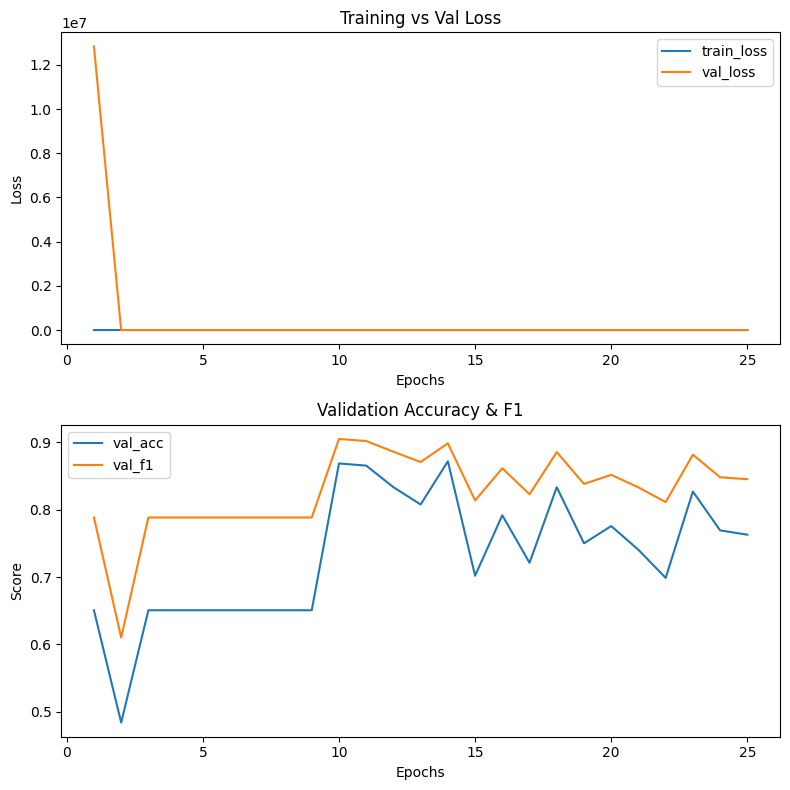

In [101]:
plot_history(final_train_history)

## 8\. Test데이터 평가

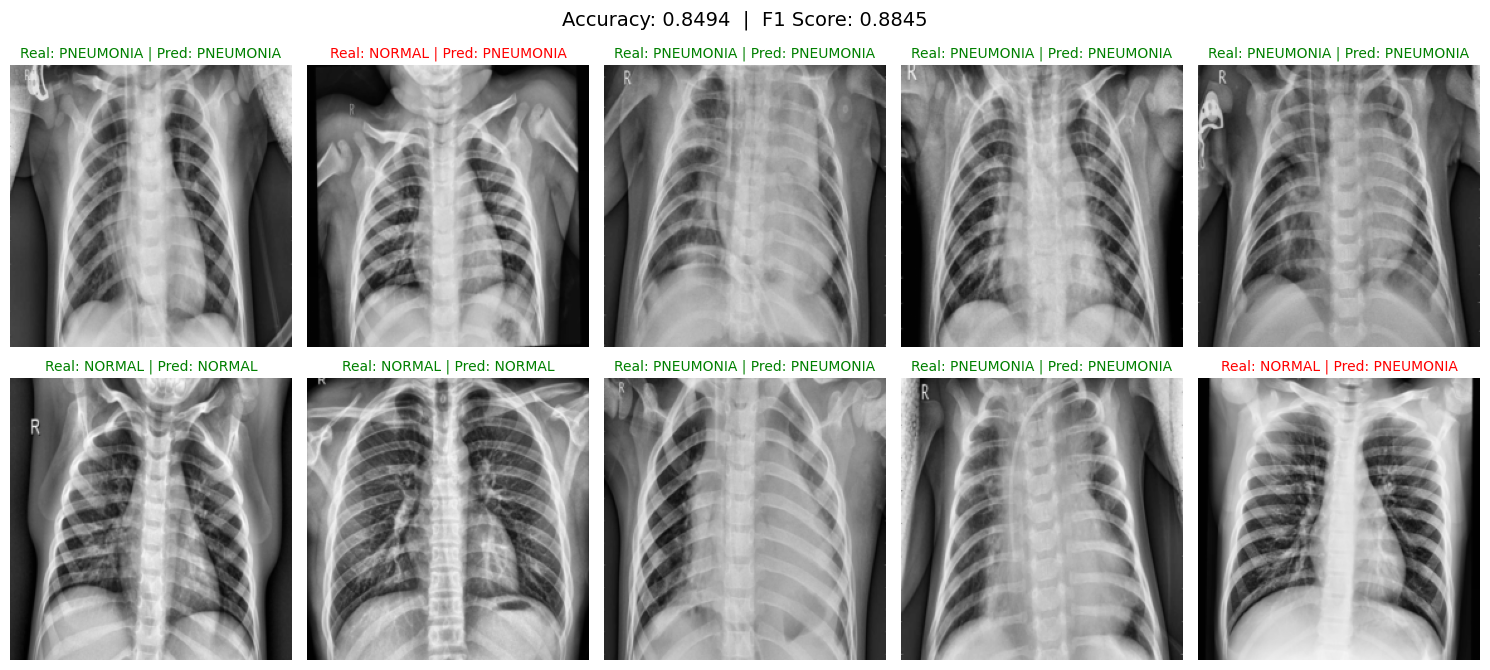

In [111]:
model = efficientnet_b1(weights = None)
model.classifier = new_classifier

model.load_state_dict(torch.load('checkpoints/final_model_best_model.pt'))
model.to(device)

accuracy = Accuracy(task='binary').to(device)
f1 = F1Score(task='binary').to(device)

img_list, label_list, pred_list = [], [], []
class_names = {0: 'NORMAL', 1: 'PNEUMONIA'}

model.eval()
with torch.no_grad() :
  for idx, (img, label) in enumerate(test_loader):
    img = img.to(device)
    label = label.float().unsqueeze(1).to(device)

    output = model(img)
    pred = torch.sigmoid(output)

    accuracy.update(pred, label)
    f1.update(pred, label)

    img_list.append(img.cpu())
    label_list.append(label.cpu())
    pred_list.append(pred.cpu())

acc = accuracy.compute().item()
f1_score = f1.compute().item()

images = torch.cat(img_list)
labels = torch.cat(label_list)
preds = torch.cat(pred_list)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle(f'Accuracy: {acc:.4f}  |  F1 Score: {f1_score:.4f}', fontsize=14)

for i, ax in enumerate(axes.flatten()):
  #Pytorch 형식 : (C, H, W), Matplotlib 형식 : (H, W, C)
  img = images[i].permute(1, 2, 0).numpy()
  img = img * 0.5 + 0.5 #역정규화

  true_label = int(labels[i].item())
  #sigmoid 출력값이 0.5 이상이면 True(PNEUMONIA)
  pred_label = int(preds[i].item() > 0.5)

  ax.imshow(img)
  ax.axis('off')
  #정답을 맞췄으면 green
  color = 'green' if true_label == pred_label else 'red'
  ax.set_title(f'Real: {class_names[true_label]} | Pred: {class_names[pred_label]}',
                color=color, fontsize=10)

plt.tight_layout()
plt.show()


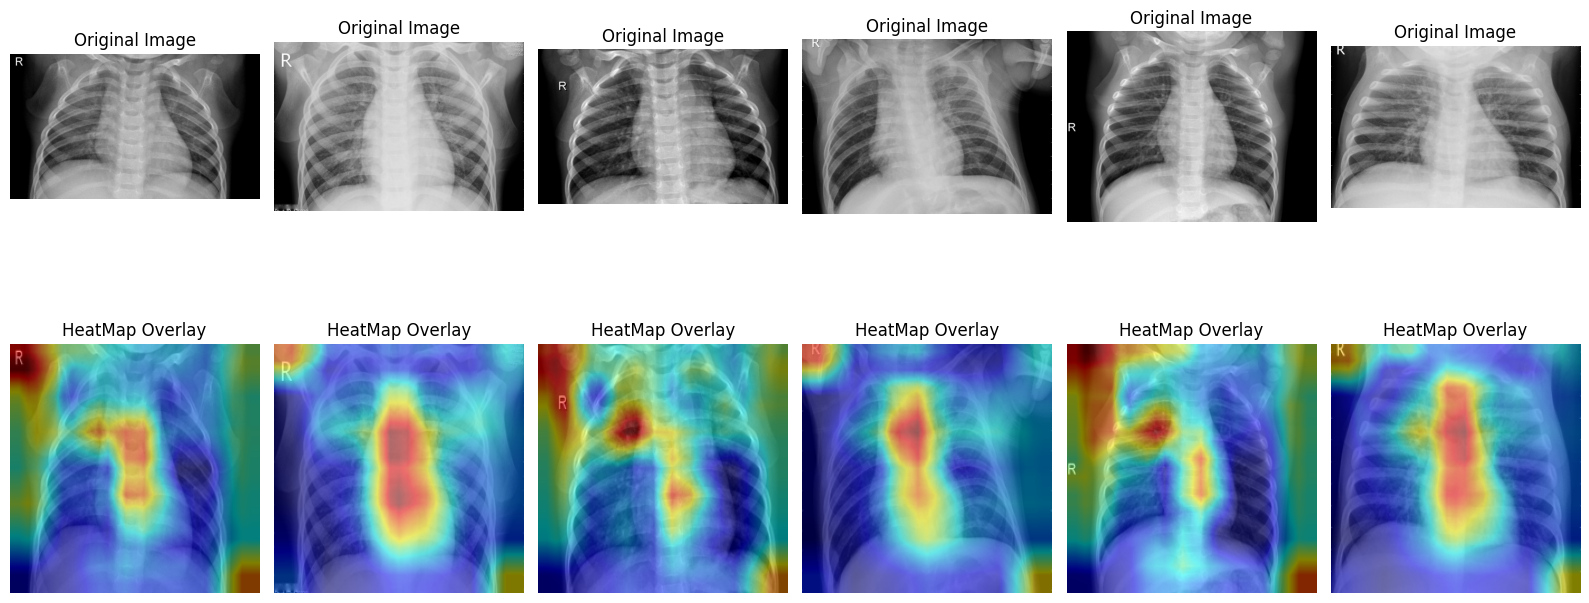

In [110]:
#LayerCam 평가

#Normal이미지 3장, PNUEUMONIA 이미지 3장
imgs_path = []

test_norm_imgs = os.listdir(os.path.join(test_dir, 'NORMAL'))[:3]
test_pneum_imgs = os.listdir(os.path.join(test_dir, 'PNEUMONIA'))[:3]

for i in range(3) :
  norm_path = os.path.join(test_dir, 'NORMAL', test_norm_imgs[i])
  pneum_path = os.path.join(test_dir, 'PNEUMONIA', test_pneum_imgs[i])

  imgs_path.append(norm_path)
  imgs_path.append(pneum_path)

target_layers = [model.features[-1], model.features[-3], model.features[-5]]
cam = LayerCAM(model=model, target_layers=target_layers)


fig, axes = plt.subplots(2, 6, figsize = (16, 8))
for i, path in enumerate(imgs_path) :

  img = Image.open(path)
  #시각화용 image
  img = img.convert("L").convert("RGB")   #GrayScale로 변환 후 3채널로 바꿈
  img_np = np.array(img.resize((224, 224))) / 255.0

  #히트맵용 tensor
  img_tensor = val_test_transforms(img).unsqueeze(0).to(device)


  heatmap = cam(input_tensor=img_tensor, targets=None)[0, :]

  #오버레이
  vis = show_cam_on_image(img_np, heatmap, use_rgb = True)

  #시각화
  axes[0][i].imshow(img)
  axes[0][i].set_title(f'Original Image')
  axes[0][i].axis('off')

  axes[1][i].imshow(vis)
  axes[1][i].set_title(f'HeatMap Overlay')
  axes[1][i].axis('off')

plt.tight_layout()
plt.show()



